In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [5]:
train_data_path = 'C:\\Users\\Dell\\Desktop\\Files\\7th_sem\\DM\\KNN\\pendigits.tra'  # Replace with the actual path
test_data_path = 'C:\\Users\\Dell\\Desktop\\Files\\7th_sem\\DM\\KNN\\pendigits.tes'  # Replace with the actual path

# Load the datasets
column_names = [f'feature_{i}' for i in range(16)] + ['digit']
train_data = pd.read_csv(train_data_path, header=None, names=column_names)
test_data = pd.read_csv(test_data_path, header=None, names=column_names)

In [6]:
# Merge the training and test datasets
data = pd.concat([train_data, test_data], ignore_index=True)

In [7]:
data.shape

(10992, 17)

In [8]:
data.head()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,digit
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [6]:
# Step 5: Drop the class variable from the data frame and save it in a different variable
X = data.drop('digit', axis=1)
y = data['digit']

In [7]:
X.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
count,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000
mean,38.814320,85.120269,40.605622,83.774199,49.770378,65.573144,51.220251,44.498999,56.868541,33.695961,60.516376,34.826510,55.022289,34.937045,47.287482,28.845342
std,34.257783,16.218571,26.342984,19.163646,34.100515,26.996688,30.576881,29.906104,34.135530,27.251548,37.288086,27.119982,22.335539,33.155463,41.760400,35.778094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,76.000000,20.000000,72.000000,18.000000,49.000000,28.000000,23.000000,29.000000,7.000000,23.000000,11.000000,42.000000,5.000000,0.000000,0.000000
50%,32.000000,89.000000,40.000000,91.000000,53.000000,71.000000,53.500000,43.000000,60.000000,33.000000,73.000000,30.000000,53.000000,27.000000,40.000000,9.000000
75%,65.000000,100.000000,58.000000,100.000000,78.000000,86.000000,74.000000,64.000000,89.000000,54.000000,97.000000,55.000000,68.000000,47.000000,100.000000,51.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Convert scaled data back to DataFrame to observe statistics
X_scaled_df = pd.DataFrame(X_scaled, columns=[f'feature_{i}' for i in range(16)])
print(X_scaled_df.describe())

          feature_0     feature_1     feature_2     feature_3     feature_4  \
count  1.099200e+04  1.099200e+04  1.099200e+04  1.099200e+04  1.099200e+04   
mean  -5.947046e-17 -4.007792e-16 -1.551403e-17  8.791286e-17  4.654210e-17   
std    1.000045e+00  1.000045e+00  1.000045e+00  1.000045e+00  1.000045e+00   
min   -1.133059e+00 -5.248560e+00 -1.541491e+00 -4.371716e+00 -1.459586e+00   
25%   -9.579082e-01 -5.623605e-01 -7.822409e-01 -6.144308e-01 -9.317110e-01   
50%   -1.989221e-01  2.392262e-01 -2.299093e-02  3.770749e-01  9.471319e-02   
75%    7.644065e-01  9.174919e-01  6.603340e-01  8.467354e-01  8.278733e-01   
max    1.786119e+00  9.174919e-01  2.254759e+00  8.467354e-01  1.473054e+00   

          feature_5     feature_6     feature_7     feature_8     feature_9  \
count  1.099200e+04  1.099200e+04  1.099200e+04  1.099200e+04  1.099200e+04   
mean   1.370406e-16  6.270255e-17 -2.117019e-17 -6.076330e-17 -9.373062e-17   
std    1.000045e+00  1.000045e+00  1.000045e+00  1.

In [10]:
# Step 10: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=43)

In [11]:
X_train.shape

(8793, 16)

In [12]:
from sklearn.metrics import accuracy_score
# Evaluate the KNN model for different values of p
for p in [1, 2, 3]:
    knn = KNeighborsClassifier(metric='minkowski', p=p)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for p={p}: {accuracy:.4f}")

Accuracy for p=1: 0.9941
Accuracy for p=2: 0.9936
Accuracy for p=3: 0.9927


In [13]:
# Define the range of n_neighbors and the list of metrics to try
n_neighbors_range = [1, 3, 5, 7, 9]
metrics = ['euclidean', 'manhattan', 'chebyshev']

# Iterate through the combinations of n_neighbors and metrics
for n_neighbors in n_neighbors_range:
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f'Accuracy with n_neighbors={n_neighbors} and metric={metric}: {accuracy:.4f}')


Accuracy with n_neighbors=1 and metric=euclidean: 0.9932
Accuracy with n_neighbors=1 and metric=manhattan: 0.9945
Accuracy with n_neighbors=1 and metric=chebyshev: 0.9909
Accuracy with n_neighbors=3 and metric=euclidean: 0.9936
Accuracy with n_neighbors=3 and metric=manhattan: 0.9945
Accuracy with n_neighbors=3 and metric=chebyshev: 0.9905
Accuracy with n_neighbors=5 and metric=euclidean: 0.9936
Accuracy with n_neighbors=5 and metric=manhattan: 0.9941
Accuracy with n_neighbors=5 and metric=chebyshev: 0.9900
Accuracy with n_neighbors=7 and metric=euclidean: 0.9927
Accuracy with n_neighbors=7 and metric=manhattan: 0.9918
Accuracy with n_neighbors=7 and metric=chebyshev: 0.9886
Accuracy with n_neighbors=9 and metric=euclidean: 0.9927
Accuracy with n_neighbors=9 and metric=manhattan: 0.9905
Accuracy with n_neighbors=9 and metric=chebyshev: 0.9882


In [14]:
# Step 11: Instantiate a "default" KNN model
knn_default = KNeighborsClassifier()


In [15]:
knn_default.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [16]:
# Step 12: Train the "default" model using the training data
knn_default.fit(X_train, y_train)

KNeighborsClassifier()

In [17]:
# Step 10: Calculate predictions on the test data
y_pred_default = knn_default.predict(X_test)

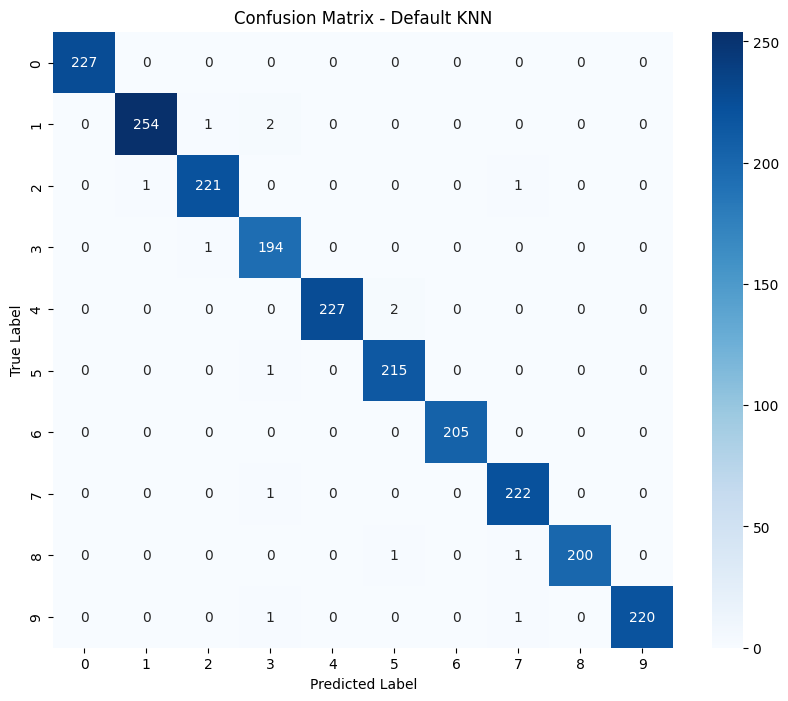

In [18]:
# Step 11: Obtain and visualize the confusion matrix
conf_matrix_default = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_default, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Default KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [19]:
# Step 12: Print the classification report
class_report_default = classification_report(y_test, y_pred_default)
print(class_report_default)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       227
           1       1.00      0.99      0.99       257
           2       0.99      0.99      0.99       223
           3       0.97      0.99      0.98       195
           4       1.00      0.99      1.00       229
           5       0.99      1.00      0.99       216
           6       1.00      1.00      1.00       205
           7       0.99      1.00      0.99       223
           8       1.00      0.99      1.00       202
           9       1.00      0.99      1.00       222

    accuracy                           0.99      2199
   macro avg       0.99      0.99      0.99      2199
weighted avg       0.99      0.99      0.99      2199



In [20]:
# Calculate Pearson correlation between features and the class variable
correlation_matrix = pd.concat([X_train, y_train], axis=1).corr(method='pearson')
correlations_with_target = correlation_matrix['digit'].drop('digit')

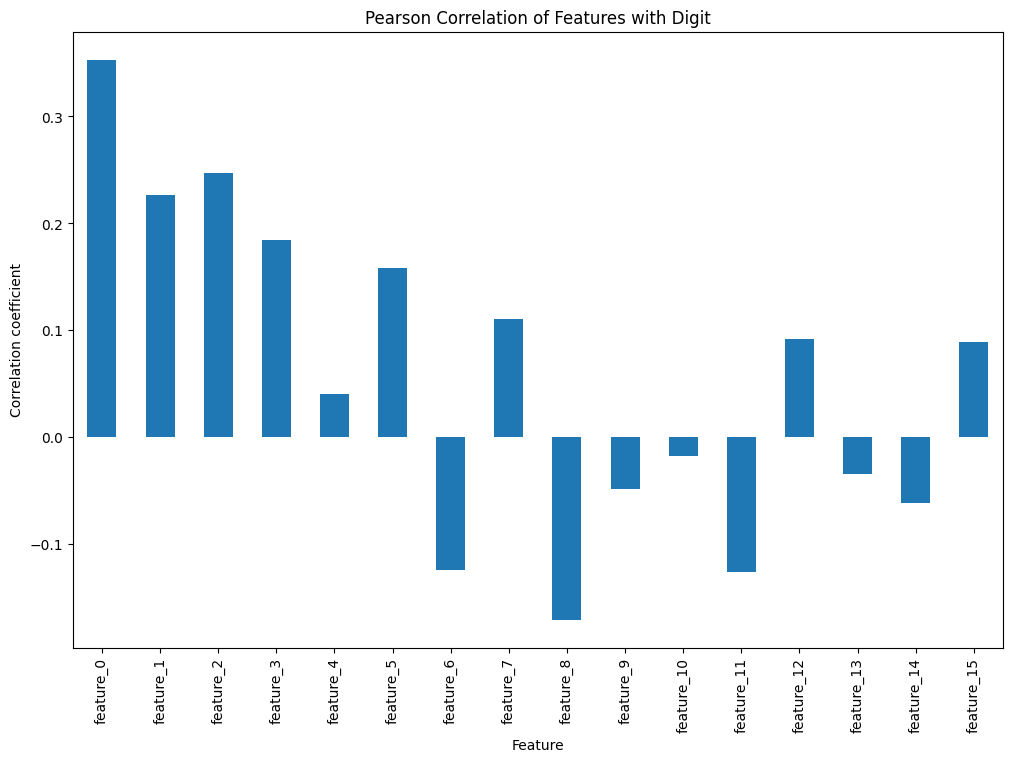

In [21]:
plt.figure(figsize=(12, 8))
correlations_with_target.plot(kind='bar')
plt.title('Pearson Correlation of Features with Digit')
plt.xlabel('Feature')
plt.ylabel('Correlation coefficient')
plt.show()

In [22]:
# Step 20: Instantiate a randomly "weighted" KNN model
# Generate random weights for each of the 16 features
random_weights = np.random.random(16)

In [23]:
# Instantiate the KNN model with the custom weights
knn_weighted = KNeighborsClassifier(metric_params={'w': random_weights})

In [24]:
# Step 21: Observe the parameters of the "weighted" KNN model
print(f'Parameters of the weighted KNN model: {knn_weighted.get_params()}')

Parameters of the weighted KNN model: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': {'w': array([0.64842173, 0.20573685, 0.12614578, 0.99395836, 0.04710815,
       0.54964517, 0.787297  , 0.93386393, 0.76971181, 0.7255032 ,
       0.25121357, 0.18593651, 0.35480672, 0.09938592, 0.26641244,
       0.90732284])}, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [25]:
# Step 22: Train the "weighted" model using the training data
knn_weighted.fit(X_train, y_train)

KNeighborsClassifier(metric_params={'w': array([0.64842173, 0.20573685, 0.12614578, 0.99395836, 0.04710815,
       0.54964517, 0.787297  , 0.93386393, 0.76971181, 0.7255032 ,
       0.25121357, 0.18593651, 0.35480672, 0.09938592, 0.26641244,
       0.90732284])})

In [26]:

# Step 23: Calculate the predictions on the testing data
y_pred_weighted = knn_weighted.predict(X_test)

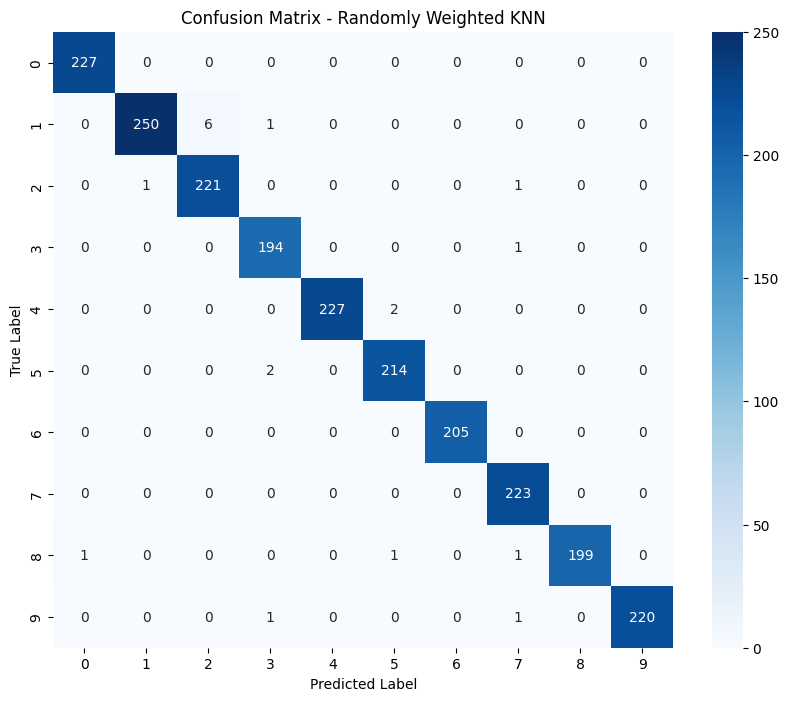

In [27]:
# Step 24: Obtain and visualize the confusion matrix
conf_matrix_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Randomly Weighted KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [28]:
# Step 25: Print the classification report
class_report_weighted = classification_report(y_test, y_pred_weighted)
print(class_report_weighted)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       227
           1       1.00      0.97      0.98       257
           2       0.97      0.99      0.98       223
           3       0.98      0.99      0.99       195
           4       1.00      0.99      1.00       229
           5       0.99      0.99      0.99       216
           6       1.00      1.00      1.00       205
           7       0.98      1.00      0.99       223
           8       1.00      0.99      0.99       202
           9       1.00      0.99      1.00       222

    accuracy                           0.99      2199
   macro avg       0.99      0.99      0.99      2199
weighted avg       0.99      0.99      0.99      2199



In [37]:
# Identify the top 4 features positively correlated with the class variable
top_4_features = correlations_with_target.nlargest(4).index.tolist()

print(top_4_features)
# Generate random weights between 1 and 4 for the top 4 features
random_weights = np.random.uniform(1, 4, size=4)

['feature_0', 'feature_2', 'feature_1', 'feature_3']


{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': {'w': array([2.77823989, 2.31065349, 2.50134282, 1.16920609])}, 'n_jobs': None, 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}


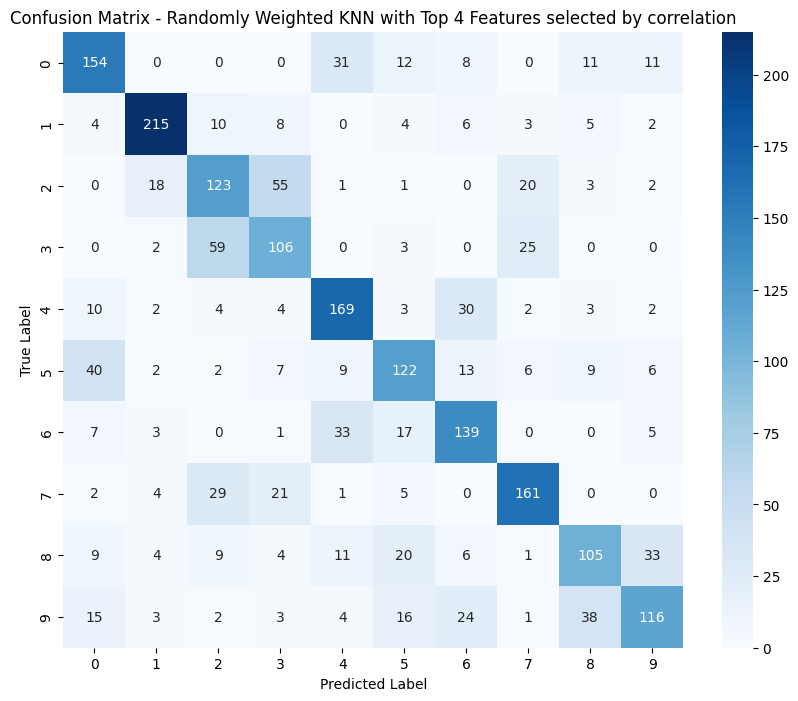

              precision    recall  f1-score   support

           0       0.64      0.68      0.66       227
           1       0.85      0.84      0.84       257
           2       0.52      0.55      0.53       223
           3       0.51      0.54      0.52       195
           4       0.65      0.74      0.69       229
           5       0.60      0.56      0.58       216
           6       0.62      0.68      0.65       205
           7       0.74      0.72      0.73       223
           8       0.60      0.52      0.56       202
           9       0.66      0.52      0.58       222

    accuracy                           0.64      2199
   macro avg       0.64      0.64      0.63      2199
weighted avg       0.64      0.64      0.64      2199



In [38]:
# Select the top 4 features for training and test datasets
X_train_top4 = X_train[top_4_features]
X_test_top4 = X_test[top_4_features]

# Instantiate the KNN model with the custom weights
knn_weighted = KNeighborsClassifier(metric="minkowski", p=1,metric_params={'w': random_weights})
print(knn_weighted.get_params())

# Train the "weighted" model using the training data with top 4 features
knn_weighted.fit(X_train_top4, y_train)

# Calculate the predictions on the testing data
y_pred_weighted = knn_weighted.predict(X_test_top4)

# Obtain and visualize the confusion matrix
conf_matrix_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Randomly Weighted KNN with Top 4 Features selected by correlation')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
# Print the classification report
class_report_weighted = classification_report(y_test, y_pred_weighted)
print(class_report_weighted)

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': {'w': array([3.44831376, 3.106864  , 2.3794347 , 3.30334762])}, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


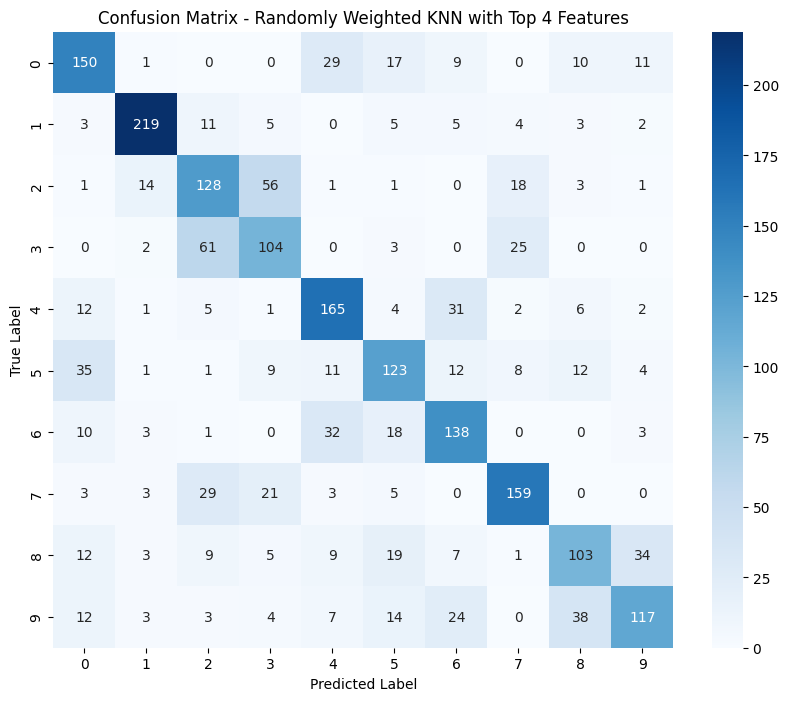

              precision    recall  f1-score   support

           0       0.63      0.66      0.65       227
           1       0.88      0.85      0.86       257
           2       0.52      0.57      0.54       223
           3       0.51      0.53      0.52       195
           4       0.64      0.72      0.68       229
           5       0.59      0.57      0.58       216
           6       0.61      0.67      0.64       205
           7       0.73      0.71      0.72       223
           8       0.59      0.51      0.55       202
           9       0.67      0.53      0.59       222

    accuracy                           0.64      2199
   macro avg       0.64      0.63      0.63      2199
weighted avg       0.64      0.64      0.64      2199



In [31]:
# Select the top 4 features for training and test datasets
X_train_top4 = X_train[top_4_features]
X_test_top4 = X_test[top_4_features]

# Instantiate the KNN model with the custom weights
knn_weighted = KNeighborsClassifier(metric="minkowski", p=2,metric_params={'w': random_weights})
print(knn_weighted.get_params())

# Train the "weighted" model using the training data with top 4 features
knn_weighted.fit(X_train_top4, y_train)

# Calculate the predictions on the testing data
y_pred_weighted = knn_weighted.predict(X_test_top4)

# Obtain and visualize the confusion matrix
conf_matrix_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Randomly Weighted KNN with Top 4 Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
# Print the classification report
class_report_weighted = classification_report(y_test, y_pred_weighted)
print(class_report_weighted)

In [32]:
# Step 2: Choose a range of k values to try with step size 2
k_values = list(range(1, 31, 2))  # For example, trying odd k values from 1 to 30

# Step 3: Perform k-Fold Cross-Validation for each k value and collect accuracy scores
accuracy_scores = []
for k in k_values:
    # Instantiate KNN model
    knn = KNeighborsClassifier(n_neighbors=k, metric_params={'w': random_weights}, weights='distance')

    # Perform k-fold cross-validation and get accuracy scores
    cv_scores = cross_val_score(knn, X_train_top4, y_train, cv=10)  # Using 10-fold cross-validation

    # Get the mean accuracy from cross-validation
    accuracy = np.mean(cv_scores)
    print(f"Average Accuracy for k={k}: {accuracy:.4f}")
    accuracy_scores.append(accuracy)

# Step 4: Find the k value with the highest accuracy
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f'Optimal k: {best_k}, Best Accuracy: {best_accuracy:.4f}')


Average Accuracy for k=1: 0.5848
Average Accuracy for k=3: 0.6179
Average Accuracy for k=5: 0.6371
Average Accuracy for k=7: 0.6468
Average Accuracy for k=9: 0.6506
Average Accuracy for k=11: 0.6557
Average Accuracy for k=13: 0.6578
Average Accuracy for k=15: 0.6598
Average Accuracy for k=17: 0.6586
Average Accuracy for k=19: 0.6590
Average Accuracy for k=21: 0.6594
Average Accuracy for k=23: 0.6596
Average Accuracy for k=25: 0.6579
Average Accuracy for k=27: 0.6570
Average Accuracy for k=29: 0.6573
Optimal k: 15, Best Accuracy: 0.6598


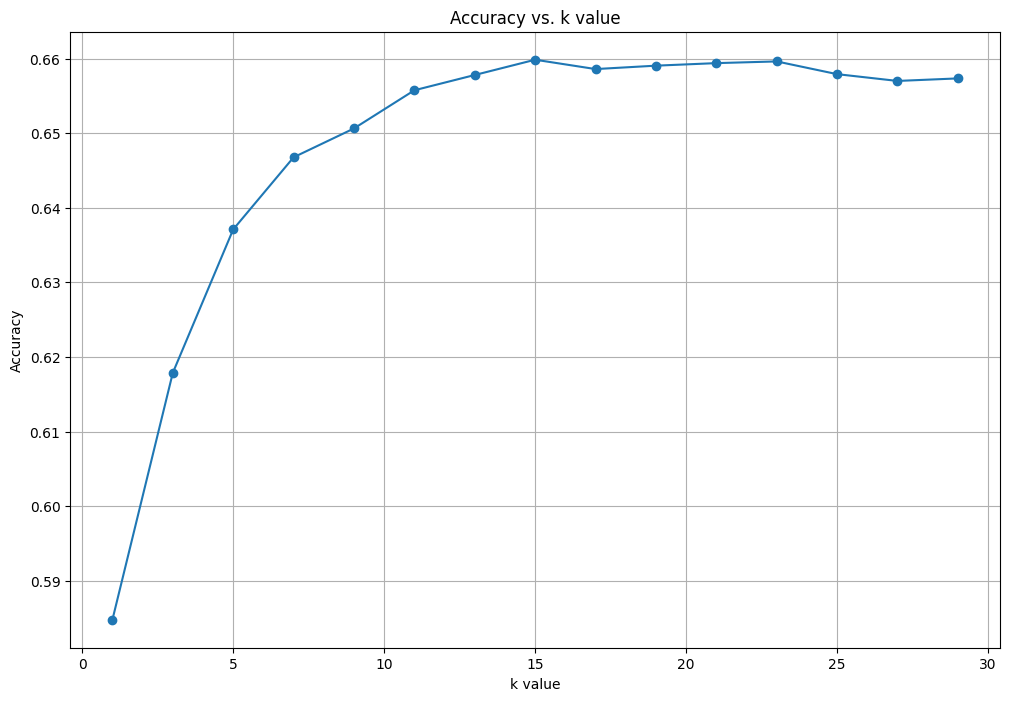

In [33]:
# Plot the accuracy vs. k values
plt.figure(figsize=(12, 8))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title('Accuracy vs. k value')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

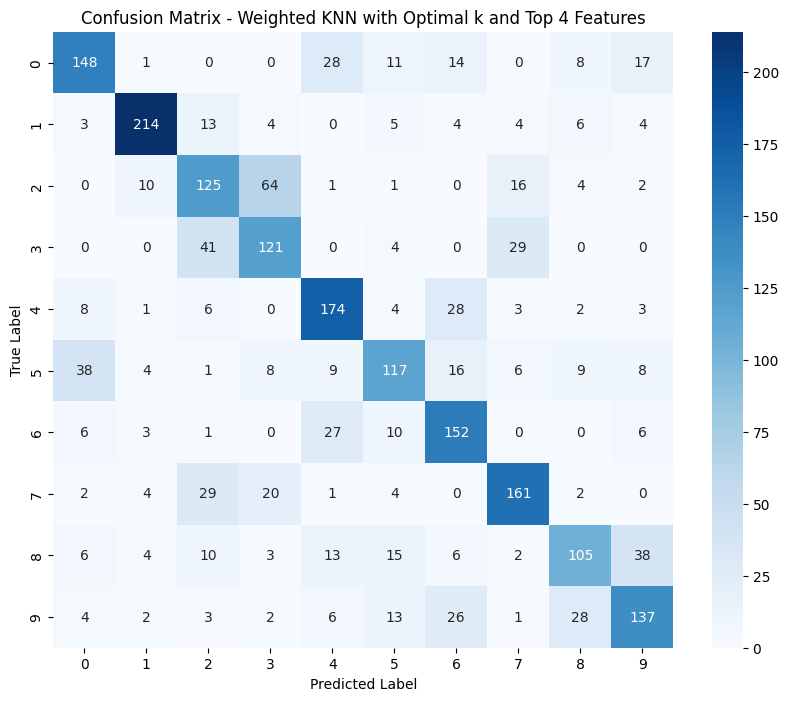

              precision    recall  f1-score   support

           0       0.69      0.65      0.67       227
           1       0.88      0.83      0.86       257
           2       0.55      0.56      0.55       223
           3       0.55      0.62      0.58       195
           4       0.67      0.76      0.71       229
           5       0.64      0.54      0.58       216
           6       0.62      0.74      0.67       205
           7       0.73      0.72      0.72       223
           8       0.64      0.52      0.57       202
           9       0.64      0.62      0.63       222

    accuracy                           0.66      2199
   macro avg       0.66      0.66      0.66      2199
weighted avg       0.66      0.66      0.66      2199



In [34]:
# Train the "weighted" model using the training data and optimal k
knn_weighted_optimal = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', metric_params={'w': random_weights}, weights='distance')
knn_weighted_optimal.fit(X_train_top4, y_train)

# Calculate predictions on the test data using the "weighted" model and optimal k
y_pred_weighted_optimal = knn_weighted_optimal.predict(X_test_top4)

# Obtain and visualize the confusion matrix
conf_matrix_weighted_optimal = confusion_matrix(y_test, y_pred_weighted_optimal)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Weighted KNN with Optimal k and Top 4 Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print the classification report
class_report_weighted_optimal = classification_report(y_test, y_pred_weighted_optimal)
print(class_report_weighted_optimal)

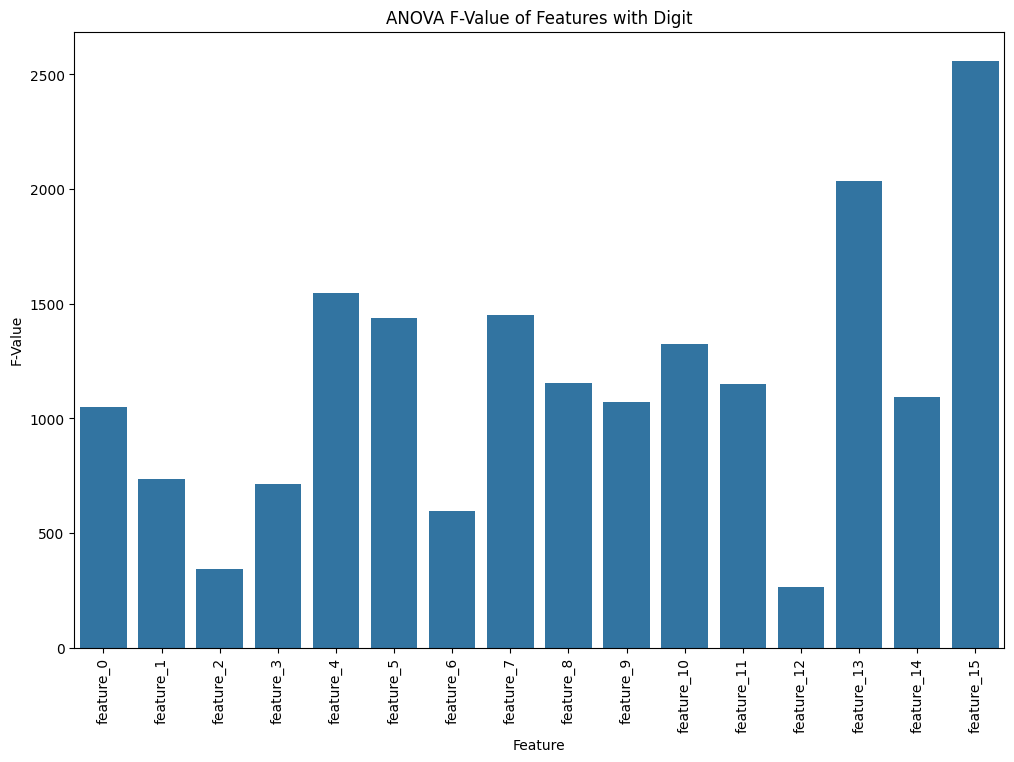

[ 7  4 13 15]
Average Accuracy for k=1: 0.7901
Average Accuracy for k=3: 0.8141
Average Accuracy for k=5: 0.8219
Average Accuracy for k=7: 0.8259
Average Accuracy for k=9: 0.8255
Average Accuracy for k=11: 0.8259
Average Accuracy for k=13: 0.8233
Average Accuracy for k=15: 0.8244
Average Accuracy for k=17: 0.8239
Average Accuracy for k=19: 0.8239
Average Accuracy for k=21: 0.8234
Average Accuracy for k=23: 0.8228
Average Accuracy for k=25: 0.8242
Average Accuracy for k=27: 0.8233
Average Accuracy for k=29: 0.8219
Optimal k: 11, Best Accuracy: 0.8259


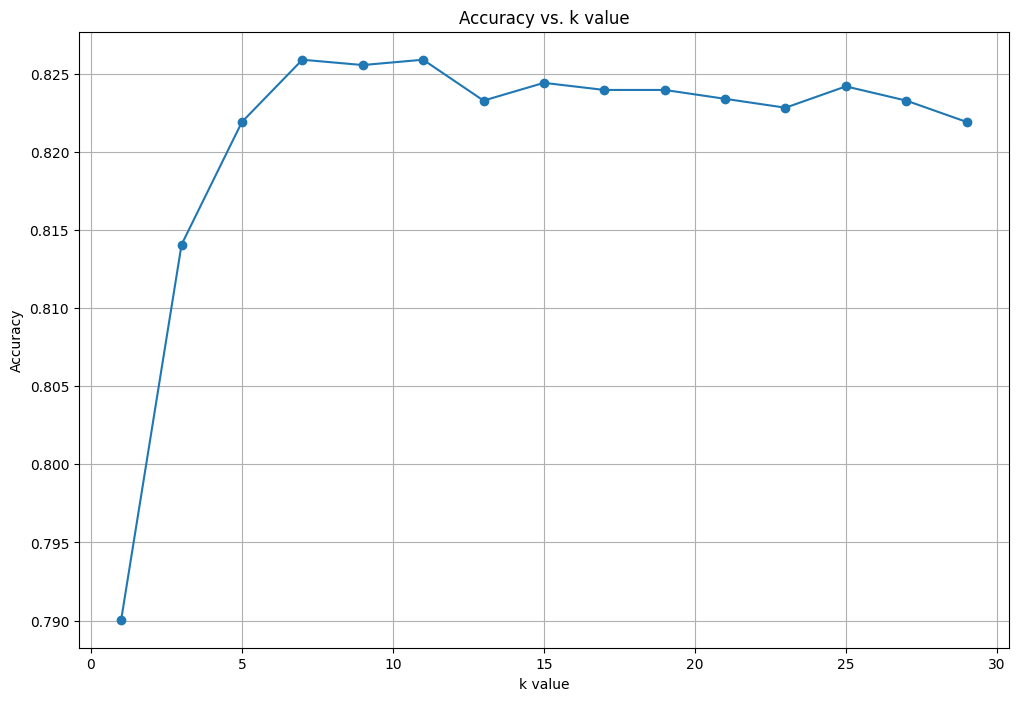

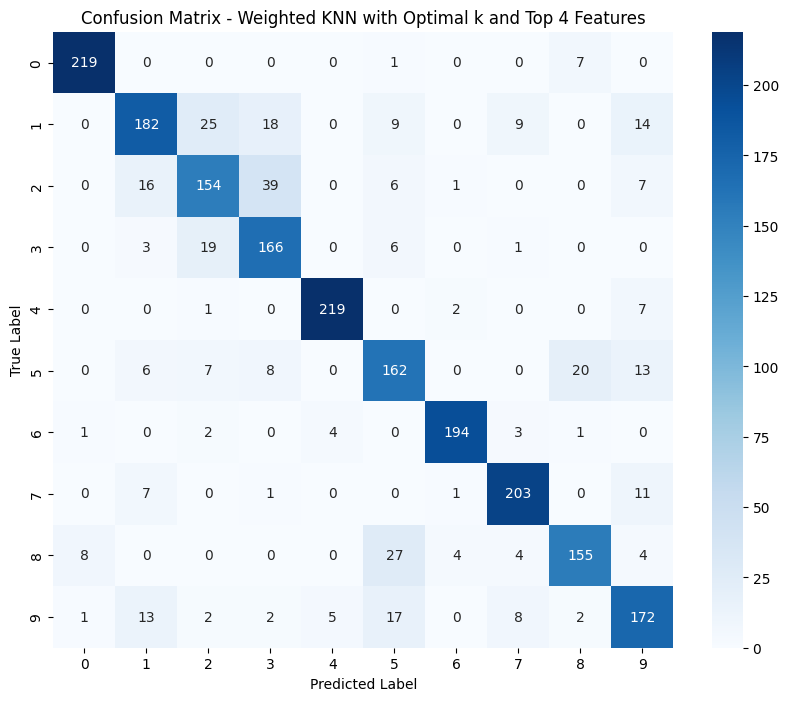

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       227
           1       0.80      0.71      0.75       257
           2       0.73      0.69      0.71       223
           3       0.71      0.85      0.77       195
           4       0.96      0.96      0.96       229
           5       0.71      0.75      0.73       216
           6       0.96      0.95      0.95       205
           7       0.89      0.91      0.90       223
           8       0.84      0.77      0.80       202
           9       0.75      0.77      0.76       222

    accuracy                           0.83      2199
   macro avg       0.83      0.83      0.83      2199
weighted avg       0.83      0.83      0.83      2199



In [40]:

from sklearn.feature_selection import f_classif
# Calculate ANOVA F-Value between features and the class variable
f_values, p_values = f_classif(X_train, y_train)

# Plot the ANOVA F-Values
plt.figure(figsize=(12, 8))
sns.barplot(x=[f'feature_{i}' for i in range(16)], y=f_values)
plt.title('ANOVA F-Value of Features with Digit')
plt.xlabel('Feature')
plt.ylabel('F-Value')
plt.xticks(rotation=90)
plt.show()

# Identify the top 4 features with the highest F-Values
top_4_features = np.argsort(f_values)[-4:]
print(top_4_features)

# Select the top 4 features for training and test datasets
X_train_top4 = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(16)]).iloc[:, top_4_features]
X_test_top4 = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(16)]).iloc[:, top_4_features]

# Step 2: Choose a range of k values to try with step size 2
k_values = list(range(1, 31, 2))  # For example, trying odd k values from 1 to 30

# Step 3: Perform k-Fold Cross-Validation for each k value and collect accuracy scores
accuracy_scores = []
for k in k_values:
    # Instantiate KNN model
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', metric_params={'w': random_weights}, weights='distance')

    # Perform k-fold cross-validation and get accuracy scores
    cv_scores = cross_val_score(knn_model, X_train_top4, y_train, cv=10)  # Using 10-fold cross-validation

    # Get the mean accuracy from cross-validation
    accuracy = np.mean(cv_scores)
    print(f"Average Accuracy for k={k}: {accuracy:.4f}")
    accuracy_scores.append(accuracy)

# Step 4: Find the k value with the highest accuracy
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f'Optimal k: {best_k}, Best Accuracy: {best_accuracy:.4f}')

# Plot the accuracy vs. k values
plt.figure(figsize=(12, 8))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title('Accuracy vs. k value')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Train the "weighted" model using the training data and optimal k
knn_weighted_optimal = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', metric_params={'w': random_weights}, weights='distance')
knn_weighted_optimal.fit(X_train_top4, y_train)

# Calculate predictions on the test data using the "weighted" model and optimal k
y_pred_weighted_optimal = knn_weighted_optimal.predict(X_test_top4)

# Obtain and visualize the confusion matrix
conf_matrix_weighted_optimal = confusion_matrix(y_test, y_pred_weighted_optimal)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Weighted KNN with Optimal k and Top 4 Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print the classification report
class_report_weighted_optimal = classification_report(y_test, y_pred_weighted_optimal)
print(class_report_weighted_optimal)


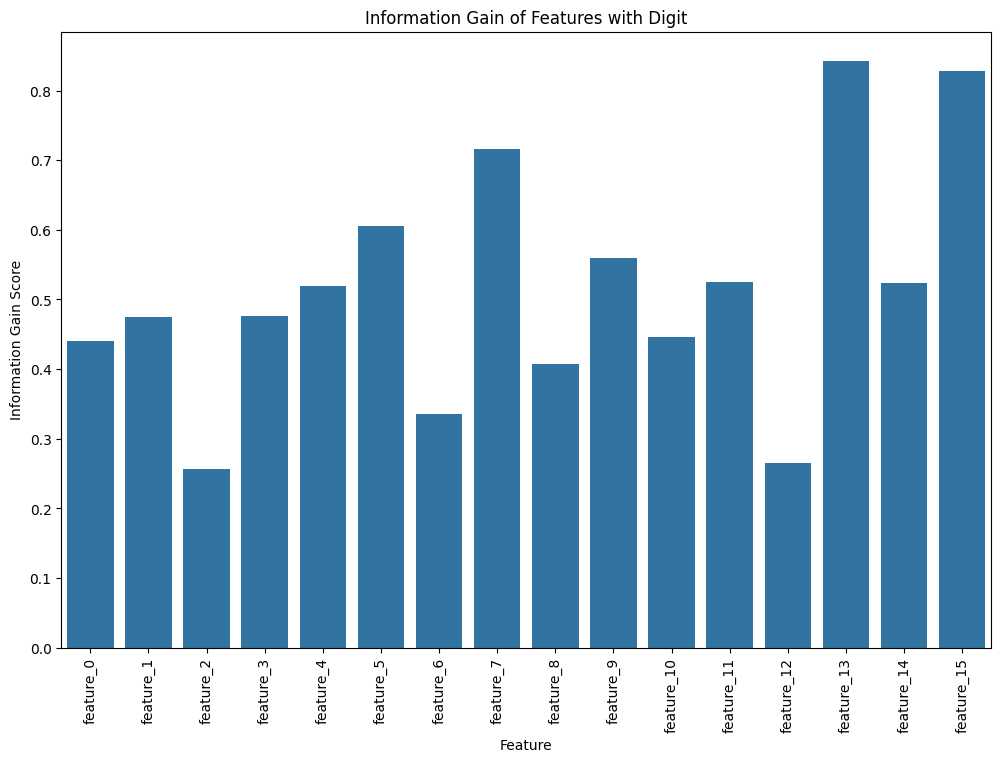

[ 5  7 15 13]
Average Accuracy for k=1: 0.7301
Average Accuracy for k=3: 0.7499
Average Accuracy for k=5: 0.7586
Average Accuracy for k=7: 0.7603
Average Accuracy for k=9: 0.7614
Average Accuracy for k=11: 0.7622
Average Accuracy for k=13: 0.7629
Average Accuracy for k=15: 0.7631
Average Accuracy for k=17: 0.7633
Average Accuracy for k=19: 0.7623
Average Accuracy for k=21: 0.7631
Average Accuracy for k=23: 0.7614
Average Accuracy for k=25: 0.7620
Average Accuracy for k=27: 0.7598
Average Accuracy for k=29: 0.7598
Optimal k: 17, Best Accuracy: 0.7633


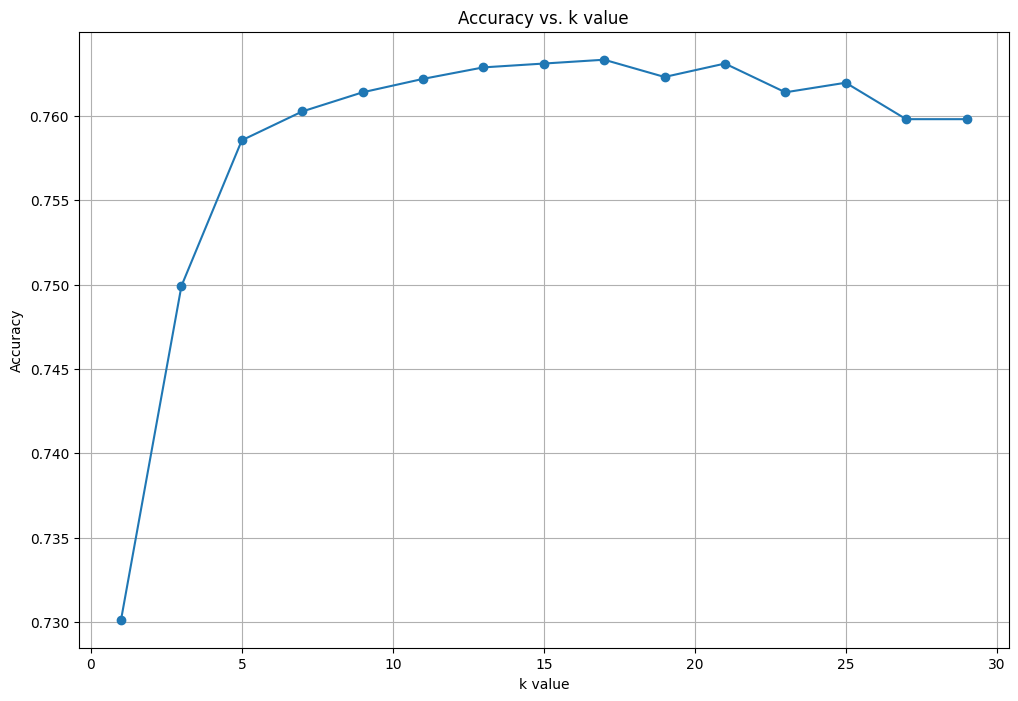

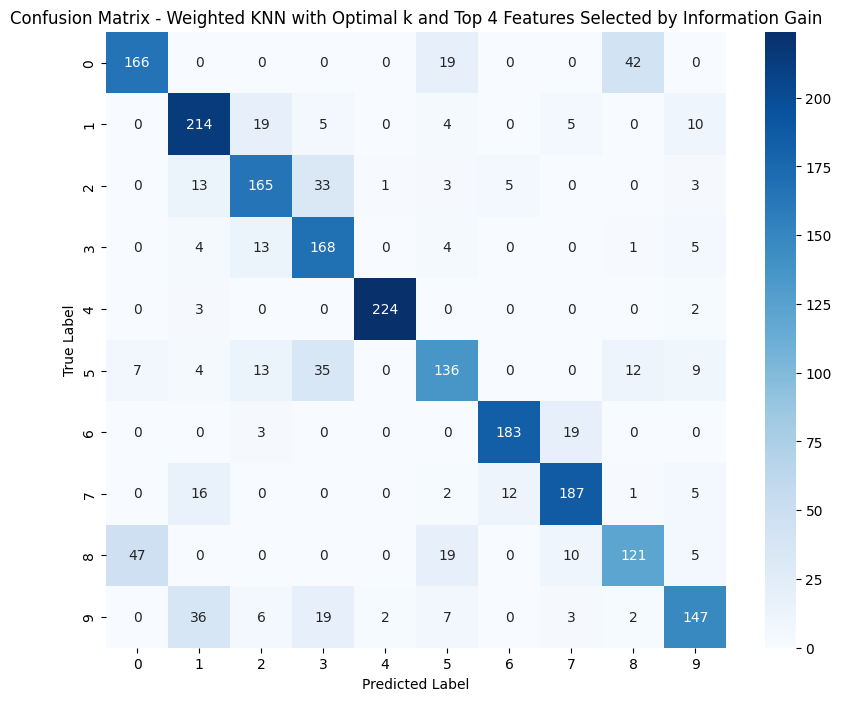

              precision    recall  f1-score   support

           0       0.75      0.73      0.74       227
           1       0.74      0.83      0.78       257
           2       0.75      0.74      0.75       223
           3       0.65      0.86      0.74       195
           4       0.99      0.98      0.98       229
           5       0.70      0.63      0.66       216
           6       0.92      0.89      0.90       205
           7       0.83      0.84      0.84       223
           8       0.68      0.60      0.64       202
           9       0.79      0.66      0.72       222

    accuracy                           0.78      2199
   macro avg       0.78      0.78      0.78      2199
weighted avg       0.78      0.78      0.78      2199



In [35]:
from sklearn.feature_selection import mutual_info_classif

# Calculate Mutual Information (Information Gain) between features and the class variable
information_gain = mutual_info_classif(X_train, y_train)

# Plot the Information Gain scores
plt.figure(figsize=(12, 8))
sns.barplot(x=[f'feature_{i}' for i in range(16)], y=information_gain)
plt.title('Information Gain of Features with Digit')
plt.xlabel('Feature')
plt.ylabel('Information Gain Score')
plt.xticks(rotation=90)
plt.show()

# Identify the top 4 features with the highest Information Gain scores
top_4_features = np.argsort(information_gain)[-4:]
print (top_4_features)

# Select the top 4 features for training and test datasets
X_train_top4 = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(16)]).iloc[:, top_4_features]
X_test_top4 = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(16)]).iloc[:, top_4_features]

# Step 2: Choose a range of k values to try with step size 2
k_values = list(range(1, 31, 2))  # For example, trying odd k values from 1 to 30

# Step 3: Perform k-Fold Cross-Validation for each k value and collect accuracy scores
accuracy_scores = []
for k in k_values:
    # Instantiate KNN model
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', metric_params={'w': random_weights}, weights='distance')

    # Perform k-fold cross-validation and get accuracy scores
    cv_scores = cross_val_score(knn_model, X_train_top4, y_train, cv=10)  # Using 10-fold cross-validation

    # Get the mean accuracy from cross-validation
    accuracy = np.mean(cv_scores)
    print(f"Average Accuracy for k={k}: {accuracy:.4f}")
    accuracy_scores.append(accuracy)

# Step 4: Find the k value with the highest accuracy
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f'Optimal k: {best_k}, Best Accuracy: {best_accuracy:.4f}')

# Plot the accuracy vs. k values
plt.figure(figsize=(12, 8))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title('Accuracy vs. k value')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Train the "weighted" model using the training data and optimal k
knn_weighted_optimal = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', metric_params={'w': random_weights}, weights='distance')
knn_weighted_optimal.fit(X_train_top4, y_train)

# Calculate predictions on the test data using the "weighted" model and optimal k
y_pred_weighted_optimal = knn_weighted_optimal.predict(X_test_top4)

# Obtain and visualize the confusion matrix
conf_matrix_weighted_optimal = confusion_matrix(y_test, y_pred_weighted_optimal)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Weighted KNN with Optimal k and Top 4 Features Selected by Information Gain')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print the classification report
class_report_weighted_optimal = classification_report(y_test, y_pred_weighted_optimal)
print(class_report_weighted_optimal)

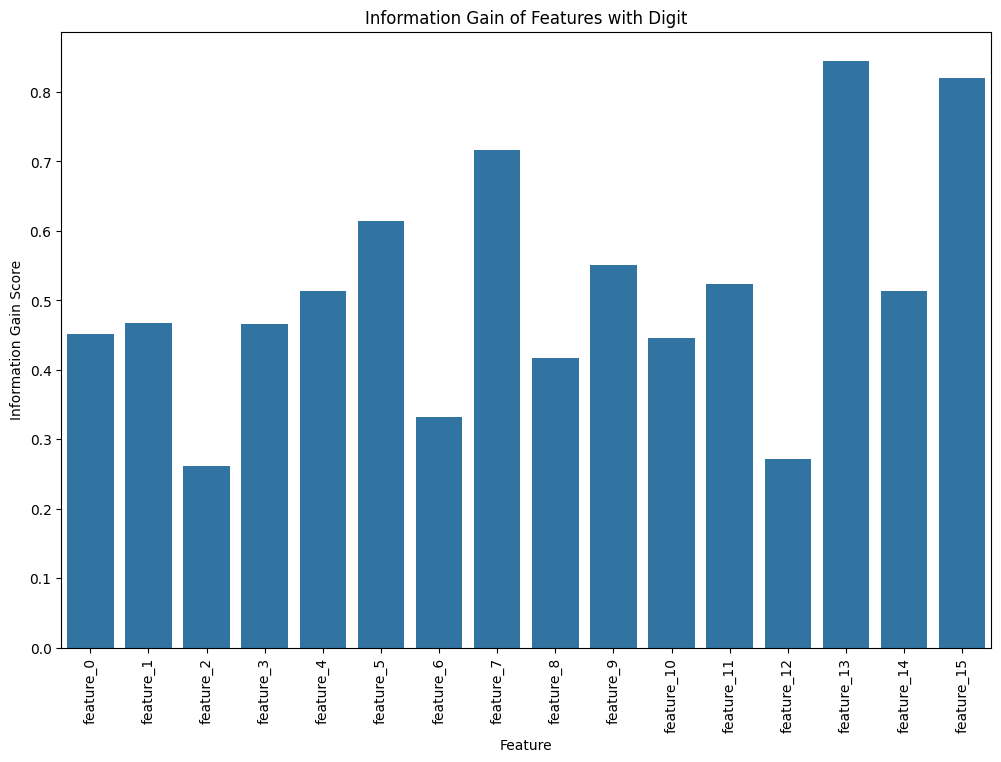

Average Accuracy for k=1: 0.9935
Average Accuracy for k=3: 0.9939
Average Accuracy for k=5: 0.9926
Average Accuracy for k=7: 0.9910
Average Accuracy for k=9: 0.9906
Average Accuracy for k=11: 0.9898
Average Accuracy for k=13: 0.9889
Average Accuracy for k=15: 0.9885
Average Accuracy for k=17: 0.9878
Average Accuracy for k=19: 0.9871
Average Accuracy for k=21: 0.9860
Average Accuracy for k=23: 0.9854
Average Accuracy for k=25: 0.9843
Average Accuracy for k=27: 0.9837
Average Accuracy for k=29: 0.9829
Optimal k: 3, Best Accuracy: 0.9939


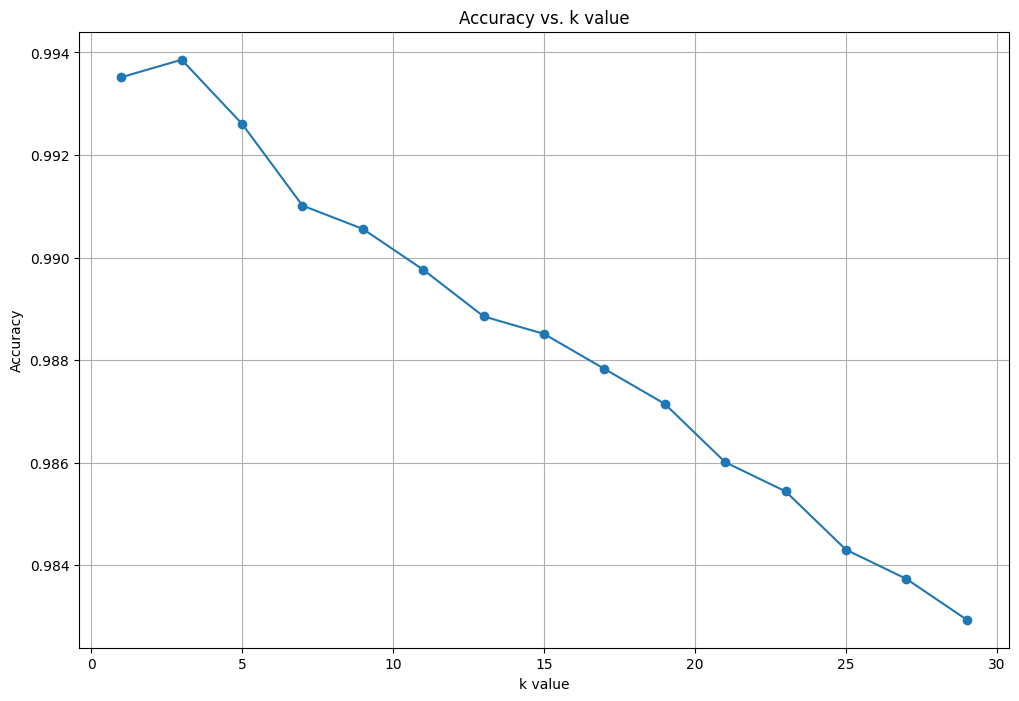

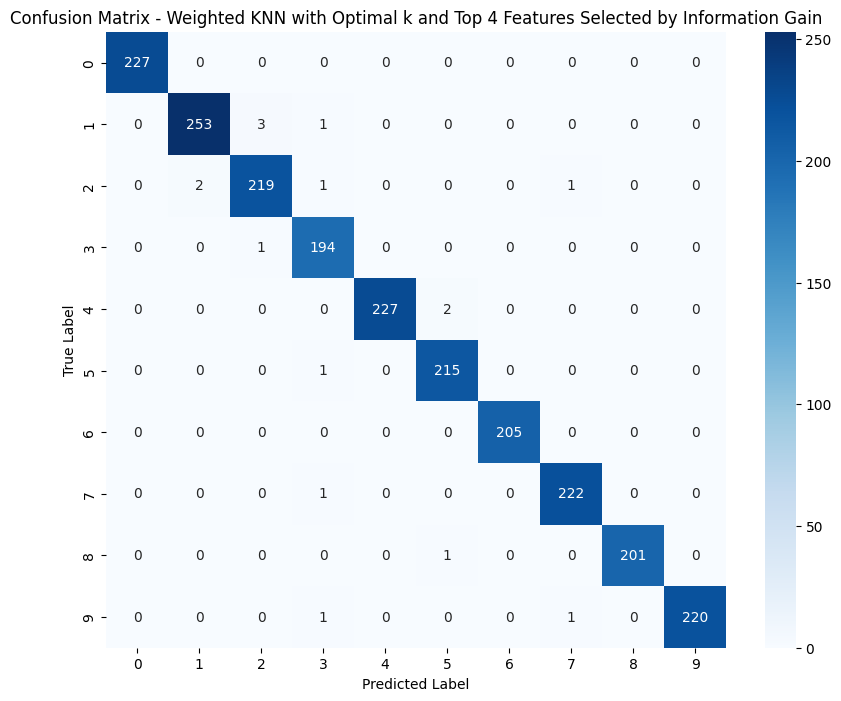

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       227
           1       0.99      0.98      0.99       257
           2       0.98      0.98      0.98       223
           3       0.97      0.99      0.98       195
           4       1.00      0.99      1.00       229
           5       0.99      1.00      0.99       216
           6       1.00      1.00      1.00       205
           7       0.99      1.00      0.99       223
           8       1.00      1.00      1.00       202
           9       1.00      0.99      1.00       222

    accuracy                           0.99      2199
   macro avg       0.99      0.99      0.99      2199
weighted avg       0.99      0.99      0.99      2199



In [232]:
from sklearn.feature_selection import mutual_info_classif

# Calculate Mutual Information (Information Gain) between features and the class variable
information_gain = mutual_info_classif(X_train, y_train)

# Plot the Information Gain scores
plt.figure(figsize=(12, 8))
sns.barplot(x=[f'feature_{i}' for i in range(16)], y=information_gain)
plt.title('Information Gain of Features with Digit')
plt.xlabel('Feature')
plt.ylabel('Information Gain Score')
plt.xticks(rotation=90)
plt.show()

# Identify the top 4 features with the highest Information Gain scores
top_4_features = np.argsort(information_gain)[-4:]

# Select the top 4 features for training and test datasets
X_train_top4 = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(16)]).iloc[:, top_4_features]
X_test_top4 = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(16)]).iloc[:, top_4_features]

# Step 2: Choose a range of k values to try with step size 2
k_values = list(range(1, 31, 2))  # For example, trying odd k values from 1 to 30

# Step 3: Perform k-Fold Cross-Validation for each k value and collect accuracy scores
accuracy_scores = []
for k in k_values:
    # Instantiate KNN model
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', weights='distance')

    # Perform k-fold cross-validation and get accuracy scores
    cv_scores = cross_val_score(knn_model, X_train, y_train, cv=10)  # Using 10-fold cross-validation

    # Get the mean accuracy from cross-validation
    accuracy = np.mean(cv_scores)
    print(f"Average Accuracy for k={k}: {accuracy:.4f}")
    accuracy_scores.append(accuracy)

# Step 4: Find the k value with the highest accuracy
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f'Optimal k: {best_k}, Best Accuracy: {best_accuracy:.4f}')

# Plot the accuracy vs. k values
plt.figure(figsize=(12, 8))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title('Accuracy vs. k value')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Train the "weighted" model using the training data and optimal k
knn_weighted_optimal = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', weights='distance')
knn_weighted_optimal.fit(X_train, y_train)

# Calculate predictions on the test data using the "weighted" model and optimal k
y_pred_weighted_optimal = knn_weighted_optimal.predict(X_test)

# Obtain and visualize the confusion matrix
conf_matrix_weighted_optimal = confusion_matrix(y_test, y_pred_weighted_optimal)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_weighted_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Weighted KNN with Optimal k and Top 4 Features Selected by Information Gain')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print the classification report
class_report_weighted_optimal = classification_report(y_test, y_pred_weighted_optimal)
print(class_report_weighted_optimal)

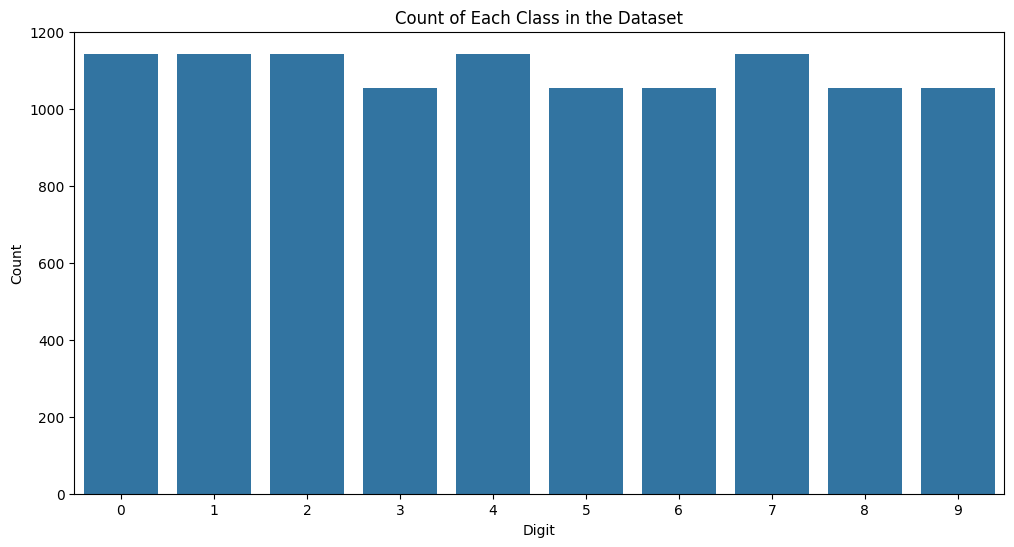

In [39]:
# Plot the count of each class
plt.figure(figsize=(12, 6))
sns.countplot(x='digit', data=data)
plt.title('Count of Each Class in the Dataset')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()